In [4]:
import numpy as np 
import qutip as qt
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scienceplots 
from scipy.special import genlaguerre, gammaln
plt.style.use(['science', 'no-latex', 'notebook'])

In [42]:
def compute_position_exponential_sparse(N, u):
    matrix = np.zeros((N, N), dtype=complex)
    for m in range(N):
        for n in range(N):
            if m >= n:
                matrix[m, n] = (
                    np.exp(-u**2 / 2)
                    * np.exp(0.5 * (gammaln(n + 1) - gammaln(m + 1)))
                    * (1.0j * u) ** (m - n)
                    * genlaguerre(n, m - n)(u**2)
                )
            else:
                matrix[m, n] = (
                    np.exp(-u**2 / 2)
                    * np.exp(0.5 * (gammaln(m + 1) - gammaln(n + 1)))
                    * (1.0j * u) ** (n - m)
                    * genlaguerre(m, n - m)(u**2)
                )
    return sp.csr_matrix(matrix)

class test_device_fock:
    def __init__(self, fock_transmon, fock_photon, omega_q, omega_r, U,  gj, gamma):
        self.fock_transmon = fock_transmon        
        self.fock_photon = fock_photon        
        self.omega_q = omega_q 
        self.omega_r = omega_r 
        self.U = U
        self.gj = gj
        self.gamma = gamma
    
    def build_hamiltonian(self, squeezing = True, linear_coupling = True):
        a = qt.destroy(self.fock_photon)
        adag = qt.destroy(self.fock_photon).dag()
        photon_num = qt.num(self.fock_photon)
        
        if linear_coupling:
            photon_op = self.gamma * (a + adag)
        else:
            sin_sparse = -0.5j * (
                compute_position_exponential_sparse(self.fock_photon, self.gamma)
                - compute_position_exponential_sparse(self.fock_photon, -self.gamma)
            )
            photon_op = qt.Qobj(sin_sparse.toarray())
        
        b = qt.destroy(self.fock_transmon)
        bdag = qt.destroy(self.fock_transmon).dag()
        transmon_num = qt.num(self.fock_transmon)
        
        if squeezing:
            transmon_op = b**2 + bdag**2 + 2 * transmon_num
        else:
            transmon_op = 2 * transmon_num
        
        photon_identity = qt.Qobj(np.eye(self.fock_photon))
        transmon_identity = qt.Qobj(np.eye(self.fock_transmon))
        
        photon_H = self.omega_r * qt.tensor(photon_num, transmon_identity)
        transmon_H = self.omega_q * qt.tensor(photon_identity, transmon_num) - self.U * qt.tensor(photon_identity, bdag**2 * b**2)
        coupling_H = self.gj * qt.tensor(photon_op, transmon_op)
        
        self.H = photon_H + transmon_H + coupling_H
        
        
class test_device:
    def __init__(self, fock_transmon, fock_photon, omega_q, omega_r, U,  gj, gamma):
        self.fock_transmon = fock_transmon        
        self.fock_photon = fock_photon        
        self.omega_q = omega_q 
        self.omega_r = omega_r 
        self.U = U
        self.gj = gj
        self.gamma = gamma
        self.EC = 2 * self.U
        self.EJ = (self.omega_q + self.EC)**2 / (8 * self.EC)
        
    def compute_cos_matrix(self):
        """
        Computes the matrix elements of cos(phi_zpf * (a + a†)) in the Fock basis.
        Uses: cos(x) = (e^{ix} + e^{-ix}) / 2
        i.e. 0.5 * (D(i*phi_zpf) + D(-i*phi_zpf))
        """
        N = self.fock_transmon
        phi_zpf = np.pow(2.0 * self.EC / self.EJ, 0.25)
        exp_plus  = compute_position_exponential_sparse(N, phi_zpf)
        exp_minus = compute_position_exponential_sparse(N, -phi_zpf)
        cos_matrix = 0.5 * (exp_plus + exp_minus)
        return cos_matrix.toarray()
    
    def build_hamiltonian(self, linear_coupling=True):
        a = qt.destroy(self.fock_photon)
        adag = a.dag()
        photon_num = qt.num(self.fock_photon)

        if linear_coupling:
            photon_op = self.gamma * (a + adag)
        else:
            sin_sparse = -0.5j * (
                compute_position_exponential_sparse(self.fock_photon, self.gamma)
                - compute_position_exponential_sparse(self.fock_photon, -self.gamma)
            )
            photon_op = qt.Qobj(sin_sparse.toarray())

        b = qt.destroy(self.fock_transmon)
        bdag = b.dag()

        charge_operator = 0.5j * (self.EJ / (2 * self.EC))**0.25 * (bdag - b)

        cos_op = qt.Qobj(self.compute_cos_matrix())

        photon_identity = qt.Qobj(np.eye(self.fock_photon))
        transmon_identity = qt.Qobj(np.eye(self.fock_transmon))

        photon_H = self.omega_r * qt.tensor(photon_num, transmon_identity)
        transmon_H = qt.tensor(photon_identity, 4 * self.EC * charge_operator**2 - self.EJ * cos_op)
        coupling_H = -2 * self.gj * qt.tensor(photon_op, cos_op)

        self.H = photon_H + transmon_H + coupling_H

In [66]:
omega_q = 1.0
U = 1/100
omega_r = 2.0 * omega_q - 6 *U
gj = 10.0
gamma_values = np.linspace(0.005, 0.05, 1000)
# gamma = 0.01
fock_transmon = 8
fock_photon = 8
spectra = []
for gamma in gamma_values:
    test_system = test_device(
        fock_photon= fock_photon,
        fock_transmon= fock_transmon,
        omega_q= omega_q,
        omega_r= omega_r,
        U= U,
        gj= gj,
        gamma= gamma
    )
    test_system.build_hamiltonian(linear_coupling= False)
    spectra.append(test_system.H.eigenenergies())

In [67]:
spectra= np.array(spectra)

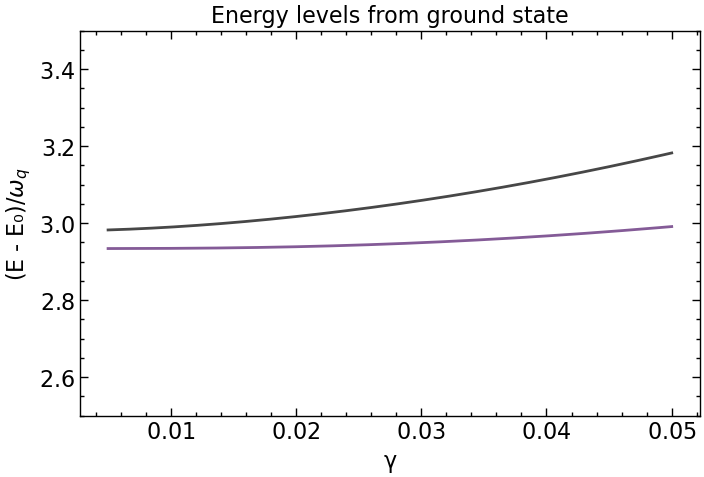

In [73]:
spectra_shifted = spectra - spectra[:, 0:1]  # col 0 is ground state, keepdims via 0:1

plt.figure(figsize=(8, 5))
plt.plot(gamma_values, spectra_shifted)
plt.xlabel("γ")
plt.ylabel(r"(E - E₀)/$\omega_q$")
plt.title("Energy levels from ground state")
plt.ylim(2.5, 3.5)  # adjust to zoom in on low-lying levels
plt.show()

In [70]:
omega_q = 1.0
U = 1/100
omega_r = 2.0 * omega_q - 2 *U
gj = 10.0
gamma_values = np.linspace(0.005, 0.05, 1000)
# gamma = 0.01
fock_transmon = 8
fock_photon = 8
spectra = []
for gamma in gamma_values:
    test_system = test_device(
        fock_photon= fock_photon,
        fock_transmon= fock_transmon,
        omega_q= omega_q,
        omega_r= omega_r,
        U= U,
        gj= gj,
        gamma= gamma
    )
    test_system.build_hamiltonian(linear_coupling= False)
    spectra.append(test_system.H.eigenenergies())

In [71]:
spectra= np.array(spectra)

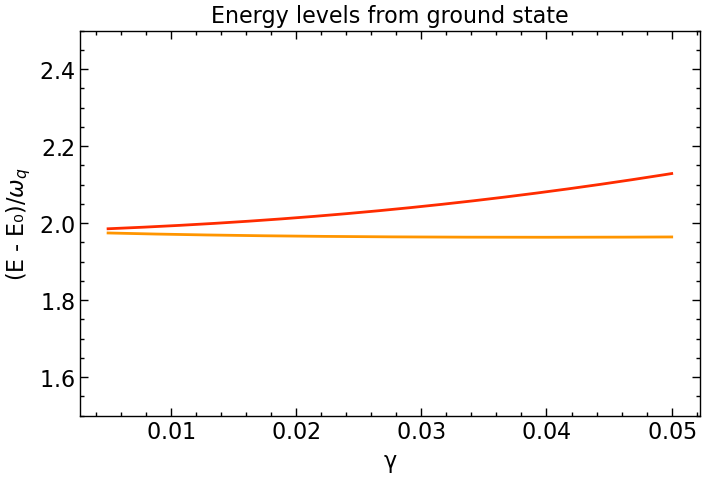

In [74]:
spectra_shifted = spectra - spectra[:, 0:1]  # col 0 is ground state, keepdims via 0:1

plt.figure(figsize=(8, 5))
plt.plot(gamma_values, spectra_shifted)
plt.xlabel("γ")
plt.ylabel(r"(E - E₀)/$\omega_q$")
plt.title("Energy levels from ground state")
plt.ylim(1.5, 2.5)  # adjust to zoom in on low-lying levels
plt.show()

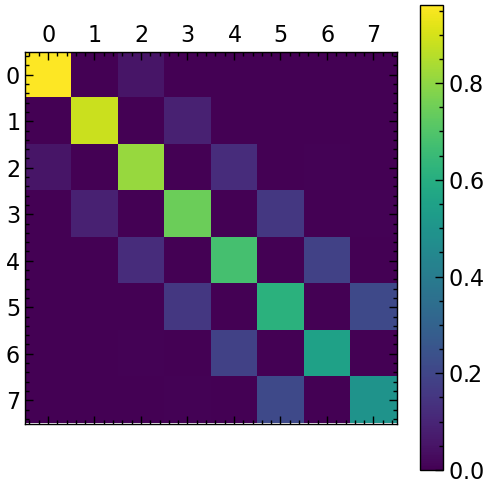

In [50]:
cos_matrix = test_system.compute_cos_matrix()
im = plt.matshow(np.abs(cos_matrix))
plt.colorbar(im)

In [51]:
cos_matrix

array([[ 9.61543295e-01+0.j,  0.00000000e+00+0.j, -5.33265713e-02+0.j,
         0.00000000e+00+0.j,  1.20737687e-03+0.j,  0.00000000e+00+0.j,
        -1.72890863e-05+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  8.86128135e-01+0.j,  0.00000000e+00+0.j,
        -8.99495772e-02+0.j,  0.00000000e+00+0.j,  2.65742733e-03+0.j,
         0.00000000e+00+0.j, -4.52301003e-05+0.j],
       [-5.33265713e-02+0.j,  0.00000000e+00+0.j,  8.13670432e-01+0.j,
         0.00000000e+00+0.j, -1.23859895e-01+0.j,  0.00000000e+00+0.j,
         4.53040661e-03+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j, -8.99495772e-02+0.j,  0.00000000e+00+0.j,
         7.44092867e-01+0.j,  0.00000000e+00+0.j, -1.55665254e-01+0.j,
         0.00000000e+00+0.j,  6.81117722e-03+0.j],
       [ 1.20737687e-03+0.j,  0.00000000e+00+0.j, -1.23859895e-01+0.j,
         0.00000000e+00+0.j,  6.77319637e-01+0.j,  0.00000000e+00+0.j,
        -1.85563329e-01+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  2.657

In [ ]:
from sq_engine import *

def 